In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)

In [13]:
df = pd.read_csv("Airline_Dataset/train.csv")

# Drop irrelevant index columns
df.drop(columns=['Unnamed: 0', 'id'], inplace=True, errors='ignore')

In [14]:
# Fill missing values
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(
    df['Arrival Delay in Minutes'].median()
)

# Encode target
df['satisfaction_encoded'] = (df['satisfaction'] == 'satisfied').astype(int)

encoders = {}
for col in ['Gender', 'Customer Type', 'Type of Travel', 'Class']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

joblib.dump(encoders, 'encoders.pkl')

['encoders.pkl']

In [18]:
feature_cols = [
    'Gender', 'Customer Type', 'Age',
    'Type of Travel', 'Class', 'Flight Distance',
    'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Inflight service', 'Cleanliness',
    'Departure Delay in Minutes', 'Arrival Delay in Minutes'
]

X = df[feature_cols]
y = df['satisfaction_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Testing  samples : {X_test.shape[0]:,}")
print(f"Features         : {len(feature_cols)}")
joblib.dump(scaler, "scaler.pkl")

Training samples : 83,123
Testing  samples : 20,781
Features         : 22


['scaler.pkl']

In [19]:
model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
model.fit(X_train_scaled, y_train)

y_pred       = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)

print(f"   Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"\n Classification Report:\n")
print(classification_report(y_test, y_pred,
      target_names=['Neutral/Dissatisfied', 'Satisfied']))

joblib.dump(model, "model.pkl")

   Accuracy : 0.8766  (87.66%)

 Classification Report:

                      precision    recall  f1-score   support

Neutral/Dissatisfied       0.88      0.90      0.89     11776
           Satisfied       0.87      0.84      0.86      9005

            accuracy                           0.88     20781
           macro avg       0.88      0.87      0.87     20781
        weighted avg       0.88      0.88      0.88     20781



['model.pkl']

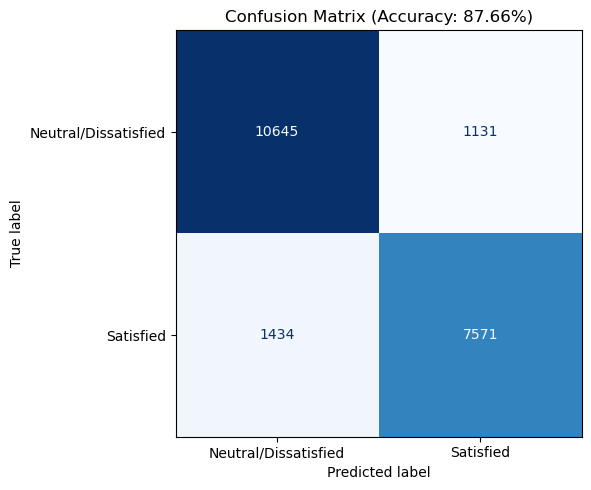

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Neutral/Dissatisfied', 'Satisfied']
)

disp.plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_title(f'Confusion Matrix (Accuracy: {acc:.2%})')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Unnamed: 0
- id
- satisfaction
